In [88]:
using SimpleEvolve
using NPZ
using Plots
using LinearAlgebra
using Optim
using LineSearches
using Random
using JLD2
using DSP   # for dpss / DPSS (Slepian) sequences
using Arpack
using FFTW
using Interpolations


In [ ]:
# -------------------------
# User / device parameters
# -------------------------
T = 22.0
println("T=", T)
Cost_ham = npzread("./../lih30/lih30.npy") 
n_qubits = round(Int, log2(size(Cost_ham, 1)))
println("n_qubits=", n_qubits)
n_levels = 2
SYSTEM = "lih30"
freqs = 2π * collect(4.8 .+ (0.02 * (1:n_qubits)))
anharmonicities = 2π * 0.3 * ones(n_qubits)
coupling_map = Dict{QubitCoupling,Float64}()
for p in 1:n_qubits
    q = (p == n_qubits) ? 1 : p + 1
    coupling_map[QubitCoupling(p, q)] = 2π * 0.02
end
device = Transmon(freqs, anharmonicities, coupling_map, n_qubits)



T=22.0
n_qubits=4


Transmon(4, [30.2849531806056, 30.410616886749196, 30.536280592892787, 30.66194429903638], [1.8849555921538759, 1.8849555921538759, 1.8849555921538759, 1.8849555921538759], Dict{QubitCoupling, Float64}(QubitCoupling(1, 2) => 0.12566370614359174, QubitCoupling(2, 3) => 0.12566370614359174, QubitCoupling(1, 4) => 0.12566370614359174, QubitCoupling(3, 4) => 0.12566370614359174))

####
1. `N` = **Number of pulse sample points** — Sets the grid resolution for control pulse (time-domain signal). More points allow finer pulse shaping.

2. `δt` = **Time step**—T/N, where `T` is total pulse duration. Defines the temporal spacing between sample points in pulse.

3. `ratio` = **Oversampling factor for DPSS generation**—Scaler to interpolate the basis more finely (denser time grid), improving smoothness and accuracy.             

4. | `N_long` = **Dense grid length**—`N * ratio`. The total number of points on the “long” grid used to build high-resolution DPSS basis functions.       

5. `W` = **Time-bandwidth product**—`4 / N_long`. Determines the spectral concentration of the Slepian (DPSS) basis. Higher `W` means broader basis. 

6. `K` = **Number of basis functions to keep (bandwidth)**—`Int(2 * N_long * W) - 1`. The number of DPSSs we use; controls model complexity and bandwidth. Typically, we select `K` so the basis captures the desired bandwidth and orthogonality.        

7. `long_dpss` = **High-resolution DPSS basis**—`dpss(N_long+1, N_long*W, K)`. Each column is a Slepian function, band-limited and time-localized. Used to represent pulses efficiently in both domains. Shape: (`N_long+1`, `K`).

8. `Φ` = **Interpolated, normalized basis matrix**—Downsampled from `long_dpss` to the main grid (`N+1` pts) via interpolation. Columns are normalized. Used to expand pulses compactly in Slepian basis. Shape: (`N+1`, `K`).

9. `x_long` = **Grid for high-res (long) DPSS functions**—A vector of time points between 0 and 1 with `N_long+1` samples.

10. `x_signal` = **Pulse sample point grid**—A vector of time points on the main control grid (`N+1` samples, matching the pulse sample locations). 

In [90]:
# ----- PARAMETERS -----
N = 10                # Number of pulse sample points (control grid)
δt= T / N             # Time step
ratio = 100          # Oversampling factor for DPSS generation
N_long = N * ratio    # Dense grid for smoothness
W = 4/ N_long             # Time-bandwidth product
K = Int(2* N_long * W) - 1  # Number of basis functions to keep (bandwidth)

# ----- BUILD SLEPIAN (DPSS) BASIS -----
long_dpss = dpss(N_long+1, N_long * W, K)  # (N_long, K)
Φ = zeros(N+1, K)
x_long = range(0, stop=1, length=N_long+1)
x_signal = range(0, stop=1, length=N+1)

for k in 1:K
    itp = LinearInterpolation(x_long, long_dpss[:,k])
    Φ[:, k] = itp.(x_signal)
    Φ[:, k] /= norm(Φ[:, k])         # Normalize columns
end

In [91]:
# ----- INITIAL PULSE -----
carrier_freqs = freqs
samples_matrix = [2π*0.0000002* sin(2π * t / N) for t in 1:N+1, q in 1:n_qubits]  # (N, n_qubits)
samples_matrix = samples_matrix .+ im .* samples_matrix           # Complex pulse at N points

# ----- PROJECT INITIAL GUESS TO SLEPIAN SPACE -----
coeffs_initial_real = zeros(K, n_qubits)
coeffs_initial_imag = zeros(K, n_qubits)
for q in 1:n_qubits
    coeffs_initial_real[:, q] = Φ \ real(samples_matrix[:, q])
    coeffs_initial_imag[:, q] = Φ \ imag(samples_matrix[:, q])
end

coeffs_initial = vcat(vec(coeffs_initial_real), vec(coeffs_initial_imag))  # Flat initial vector


56-element Vector{Float64}:
 -1.1264748188879991e-6
  1.91268650982486e-6
  3.998706342475805e-7
  1.1345766076782005e-6
  7.743557423308202e-7
  4.560408677833965e-7
  8.722757974742989e-7
 -1.1264748188879991e-6
  1.91268650982486e-6
  3.998706342475805e-7
  ⋮
  4.560408677833965e-7
  8.722757974742989e-7
 -1.1264748188879991e-6
  1.91268650982486e-6
  3.998706342475805e-7
  1.1345766076782005e-6
  7.743557423308202e-7
  4.560408677833965e-7
  8.722757974742989e-7

In [92]:
# -------------------------
# Ground state (Hartree-Fock)
# initial_state_ground = "1100"
initial_state_ground = "0011"
ψ_initial_g = zeros(ComplexF64, n_levels^n_qubits)
ψ_initial_g[1+parse(Int, initial_state_ground, base=n_levels)] = 1.0 + 0im
ψ_initial = copy(ψ_initial_g)

H_static = static_hamiltonian(device, n_levels)
drives = a_fullspace(n_qubits, n_levels)
eigvalues, eigvectors = eigen(Hermitian(H_static))
println("Eignvalues of our static Hamiltonian")
display(eigvalues)
tol_ode = 1e-6
Λ, U = eigs(Cost_ham)
E_actual = Λ[1]
println("Actual energy: $E_actual")

for i in 1:n_qubits
    drives[i] = eigvectors' * drives[i] * eigvectors
end

16-element Vector{Float64}:
   0.0
  30.159289474462064
  30.410616886749224
  30.53628059289281
  30.787608005179976
  60.526027410461616
  60.77909951657112
  60.946897479642
  60.94689747964202
  61.11469544271285
  61.36776754882242
  91.10618695410398
  91.35751436639117
  91.4831780725348
  91.73450548482195
 121.89379495928395

Eignvalues of our static Hamiltonian
Actual energy: -7.798363430684725 - 2.01731536655675e-16im


In [93]:

# ----- HELPER: RECONSTRUCT PULSE FROM COEFFS -----
function coeffs_to_samples_matrix(coeffs::Vector{Float64})
    nK = K * n_qubits
    real_flat = coeffs[1:nK]
    imag_flat = coeffs[nK+1:end]
    coeffs_real = reshape(real_flat, K, n_qubits)
    coeffs_imag = reshape(imag_flat, K, n_qubits)
    samples_real = Φ * coeffs_real
    samples_imag = Φ * coeffs_imag
    return samples_real .+ im .* samples_imag  # (N, n_qubits)
end
function apply_lowpass!(samples_complex, sample_rate, filter_order, n_qubits)
    fs = 1 / sample_rate
    cutoff = fs / 2.0001

    fft_before = Matrix{ComplexF64}(undef, size(samples_complex, 1), n_qubits)

    for i in 1:n_qubits
        pulse = samples_complex[:, i]
        fft_before[:, i] = fft(pulse)
        filtered_pulse = SimpleEvolve.lowpass_filter(pulse, cutoff, fs; order=filter_order)
        samples_complex[:, i] = filtered_pulse
    end

    return samples_complex
end

apply_lowpass! (generic function with 1 method)

In [94]:
penalty = true
sample_rate=0.2
n_samples = N 
# ----- COST FUNCTION -----
function costfunction_coeffs(coeffs::Vector{Float64})
    samples_complex = coeffs_to_samples_matrix(coeffs)
    # Apply lowpass filter before sending to device for frequency bandwidth constraint
    # samples_complex = apply_lowpass!(samples_complex, sample_rate, 4, n_qubits)  # order=8 example

    # Build signals
    signals = MultiChannelSignal([DigitizedSignal(samples_complex[:, i], δt, carrier_freqs[i]) for i in 1:n_qubits])

    # Compute energy (call SimpleEvolve)
    if penalty == true
        energy, Ψ_ode = SimpleEvolve.costfunction_ode_with_penalty(
            ψ_initial, eigvalues, signals, n_qubits, drives, eigvectors, T, Cost_ham;
            basis="qubitbasis", tol_ode=tol_ode)
    else
        energy, Ψ_ode = SimpleEvolve.costfunction_ode(
            ψ_initial, eigvalues, signals, n_qubits, drives, eigvectors, T, Cost_ham;
            basis="qubitbasis", tol_ode=tol_ode
        )
    end
    return energy
end
∂Ω_real= zeros(Float64, N+1, n_qubits)
∂Ω_imag= zeros(Float64, N+1, n_qubits)

11×4 Matrix{Float64}:
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0

In [95]:
# ----- GRADIENT FUNCTION -----
function gradient_coeffs!(Grad::Vector{Float64}, coeffs::Vector{Float64};Ω₀=2π*0.02,λ=1.0)
    samples_complex = coeffs_to_samples_matrix(coeffs)
    # Apply lowpass filter before sending to device
    # samples_complex = apply_lowpass!(samples_complex, sample_rate, 4, n_qubits)  # order=8 example

    # build signal objects (DigitizedSignal expects vector of complex samples)
    signals = MultiChannelSignal([
        DigitizedSignal(samples_complex[:, i], δt, carrier_freqs[i])
        for i in 1:n_qubits
    ])

    # Call gradient routine from SimpleEvolve (returns time-domain gradients)
    # We expect ∂Ω_real, ∂Ω_imag each of size (n_time, n_qubits)
    ∂Ω_real, ∂Ω_imag, ψ_ode, σ_ode = SimpleEvolve.gradientsignal_ODE(
        ψ_initial, T, signals, n_qubits, drives, eigvalues, eigvectors,
        Cost_ham, n_samples;
        basis="qubitbasis", tol_ode=tol_ode
    )

    # Project time-domain gradients onto Slepian basis:
    # grad_coeffs_real(:, q) = Φ' * ∂Ω_real[:, q] (size K)
    grad_real = Φ' * ∂Ω_real    # K × n_qubits
    grad_imag = Φ' * ∂Ω_imag    # K × n_qubits


    # Grad is a flat vector of size 2 * K * n_qubits
    grad_vec = vcat(vec(grad_real), vec(grad_imag))
    # Apply amplitude penalty (mapped to coefficient space)
    if penalty
        # We apply a simple amplitude penalty by mapping time-domain amplitude to coefficients gradient.
        # A direct mapping of the sample-space penalty used originally is more involved (nonlinear), but
        # here we project the sample-space penalty gradient into coefficient space as well.
        # Compute sample amplitudes and penalty gradient in sample space, then project:
        samples_flat = vec(samples_complex)                 # (n_time*n_qubits)
        # build sample penalty gradient (same shape)
        sample_penalty_grad = zeros(ComplexF64, size(samples_complex))
        for q in 1:n_qubits
            for ti in 1:N+1
                x = samples_complex[ti, q] / Ω₀
                y = abs(x) - 1
                g = 0.0 + 0.0im
                if y > 0
                    h = exp(y - 1 / y)
                    # derivative of h wrt x magnitude: dh_d|x| = h * (1 + 1/y^2) * (1/Ω₀)
                    dh_dmag = h * (1 + 1 / y^2) / Ω₀
                    # derivative wrt complex x: dh/dx = dh_dmag * x/|x|
                    g = dh_dmag * (x / max(abs(x), eps()))
                end
                sample_penalty_grad[ti, q] = g
            end
        end

        # project sample penalty grad to coefficient space
        # separate into real/imag parts
        sample_pen_real = real(sample_penalty_grad)
        sample_pen_imag = imag(sample_penalty_grad)
        pen_coeffs_real = Φ' * sample_pen_real
        pen_coeffs_imag = Φ' * sample_pen_imag
        grad_vec .+= λ * vcat(vec(pen_coeffs_real), vec(pen_coeffs_imag))
    end

    Grad .= grad_vec
    return Grad
end


gradient_coeffs! (generic function with 1 method)

In [96]:
@time energy_hf = begin
    # zero coefficients for HF baseline
    zeros_coeffs = zeros(length(coeffs_initial))
    costfunction_coeffs(zeros_coeffs)
end
println("Hartree Fock energy ", energy_hf)
@time energy1 = costfunction_coeffs(coeffs_initial)
println("initial energy ", energy1)
# -------------------------
# optimization setup (optimize coefficients)
# -------------------------
linesearch = LineSearches.MoreThuente()
optimizer = Optim.LBFGS(linesearch=linesearch)
options = Optim.Options(
    show_trace=true,
    show_every=1,
    f_reltol=1e-12,
    g_tol   =1e-8,
    iterations=1000,
)

  0.028313 seconds (40.71 k allocations: 2.384 MiB, 96.80% compilation time)
Hartree Fock energy -7.710829899999981
  0.000550 seconds (4.36 k allocations: 834.797 KiB)
initial energy -7.710829865921056


                x_abstol = 0.0
                x_reltol = 0.0
                f_abstol = 0.0
                f_reltol = 1.0e-12
                g_abstol = 1.0e-8
          outer_x_abstol = 0.0
          outer_x_reltol = 0.0
          outer_f_abstol = 0.0
          outer_f_reltol = 0.0
          outer_g_abstol = 1.0e-8
           f_calls_limit = 0
           g_calls_limit = 0
           h_calls_limit = 0
       allow_f_increases = true
 allow_outer_f_increases = true
        successive_f_tol = 1
              iterations = 1000
        outer_iterations = 1000
             store_trace = false
           trace_simplex = false
              show_trace = true
          extended_trace = false
           show_warnings = true
              show_every = 1
                callback = nothing
              time_limit = NaN


In [97]:
# multi-stage tightening of ODE tolerance, as in your original script
tol_ode = 1e-4
optimization = Optim.optimize(costfunction_coeffs, gradient_coeffs!, coeffs_initial, optimizer, options)
coeffs_final = Optim.minimizer(optimization)
tol_ode = 1e-6
optimization = Optim.optimize(costfunction_coeffs, gradient_coeffs!, coeffs_final, optimizer, options)
coeffs_final = Optim.minimizer(optimization)
tol_ode = 1e-8
optimization = Optim.optimize(costfunction_coeffs, gradient_coeffs!, coeffs_final, optimizer, options)
coeffs_final = Optim.minimizer(optimization)
tol_ode = 1e-10
optimization = Optim.optimize(costfunction_coeffs, gradient_coeffs!, coeffs_final, optimizer, options)
coeffs_final = Optim.minimizer(optimization)


Iter     Function value   Gradient norm 
     0    -7.710830e+00     2.857081e-02
 * time: 4.982948303222656e-5
     1    -7.720010e+00     2.044621e-02
 * time: 0.051323890686035156
     2    -7.725489e+00     2.121542e-02
 * time: 0.059044837951660156
     3    -7.734396e+00     2.851088e-02
 * time: 0.06801390647888184
     4    -7.741001e+00     4.915425e-02
 * time: 0.07761979103088379
     5    -7.748903e+00     2.582070e-02
 * time: 0.08952188491821289
     6    -7.757334e+00     2.035504e-02
 * time: 0.0998377799987793
     7    -7.763036e+00     2.318690e-02
 * time: 0.11246585845947266
     8    -7.771758e+00     1.851426e-02
 * time: 0.12326979637145996
     9    -7.773636e+00     3.669228e-02
 * time: 0.13557887077331543
    10    -7.781605e+00     1.247806e-02
 * time: 0.1466069221496582
    11    -7.782939e+00     1.104455e-02
 * time: 0.15881800651550293
    12    -7.786565e+00     8.146118e-03
 * time: 0.17002391815185547
    13    -7.787650e+00     1.314257e-02
 * time

56-element Vector{Float64}:
  0.027842750277388077
  0.050526513644086106
 -0.04221249641351569
 -0.05186328742253697
 -0.001266887203951101
 -0.1485579052483352
  0.07325074603065947
 -0.09336592708614225
 -0.040519091033510785
 -0.09930350036801165
  ⋮
  0.06132216572390158
 -0.0525957684973738
  0.1345636681799984
  0.062074821074284935
 -0.06973685432299562
  0.06650678269090184
 -0.03163811134434612
 -0.08240441643096606
 -0.09854731369142437

In [98]:

# ----- RECONSTRUCT FINAL PULSE --------
samples_final = coeffs_to_samples_matrix(coeffs_final)  # (N, n_qubits)
@save "results_slepian_LiH_K_$(K).jld2" samples_final coeffs_final 
Ω = samples_final
pulse_windows = range(0, T, length=N+1)  # Time windows for plotting

Ω_plots = plot(
    [plot(pulse_windows, real.(Ω[:, q])) for q in 1:n_qubits]...,
    title="Final Signals (real)",
    legend=false,
    layout=(n_qubits, 1),
)
Ω_plots_final = plot(
    [plot(pulse_windows, imag.(Ω[:, q])) for q in 1:n_qubits]...,
    title="Final Signals (imag)",
    legend=false,
    layout=(n_qubits, 1),
)
plot(Ω_plots, Ω_plots_final, layout=(1, 2))
savefig("final_signals_$(n_qubits)_$(n_levels)_$(SYSTEM)_$(n_samples)_$(T)_slepian_K_$(K).png")


"/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/final_signals_4_2_lih30_10_22.0_slepian_K_7.png"

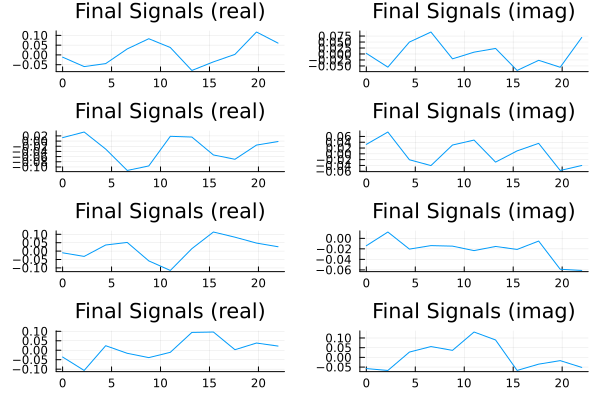

In [99]:
using Images
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/final_signals_4_2_lih30_10_22.0_slepian_K_39.png")
display(img)
# run(`open /Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/final_signals_4_2_lih30_20_22.0_slepian.pdf`)

In [100]:
nK = K * n_qubits

# Reshape for each qubit, real and imag
coeffs_final_real = reshape(coeffs_final[1:nK], K, n_qubits)
coeffs_final_imag = reshape(coeffs_final[nK+1:end], K, n_qubits)
pulse_long_real= zeros(Float64, N_long+1, n_qubits)
pulse_long_imag= zeros(Float64, N_long+1, n_qubits)
for q in 1:n_qubits
    # For qubit q, reconstruct its real and imag pulse on the long grid:
    pulse_long_real = long_dpss * coeffs_final_real[:, q]
    pulse_long_imag = long_dpss * coeffs_final_imag[:, q]
end


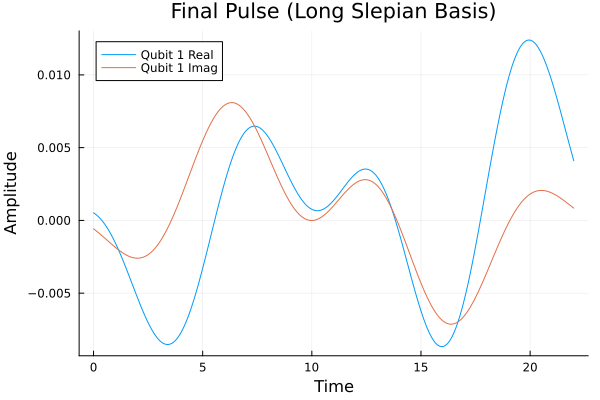

In [101]:
# Full complex pulse:
pulse_long = pulse_long_real + im * pulse_long_imag
x_long = range(0, T, length=N_long+1)
# plot(x_long, real(pulse_long), label="Qubit 1 Real", xlabel="Time", ylabel="Amplitude", title="Final Pulse (Long Slepian Basis)")
# plot!(x_long, imag(pulse_long), label="Qubit 1 Imaginary")
# savefig("final_pulse_qubit_1_long_slepian.pdf")
for q in 1:n_qubits
    pulse_long_real= zeros(Float64, N_long+1, n_qubits)
    pulse_long_imag= zeros(Float64, N_long+1, n_qubits)
    x_long = range(0, T, length=N_long+1)
    pulse_long_real = long_dpss * coeffs_final_real[:, q]
    pulse_long_imag = long_dpss * coeffs_final_imag[:, q]
    pulse_long      = pulse_long_real + im * pulse_long_imag

    plot(x_long, real(pulse_long), label="Qubit $q Real", xlabel="Time", ylabel="Amplitude", title="Final Pulse (Long Slepian Basis)")
    plot!(x_long, imag(pulse_long), label="Qubit $q Imag")
    savefig("final_pulse_qubit$(q)_long_slepian.png")
end
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/final_pulse_qubit1_long_slepian.png")
display(img)

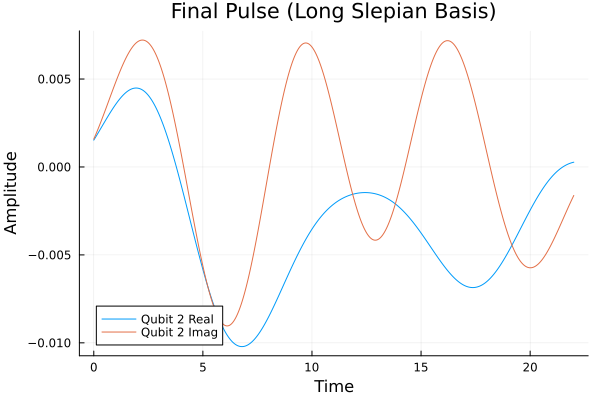

In [102]:
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/final_pulse_qubit2_long_slepian.png")
display(img)

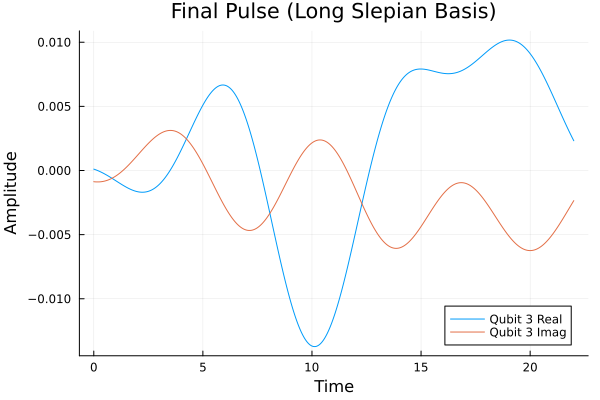

In [103]:
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/final_pulse_qubit3_long_slepian.png")
display(img)

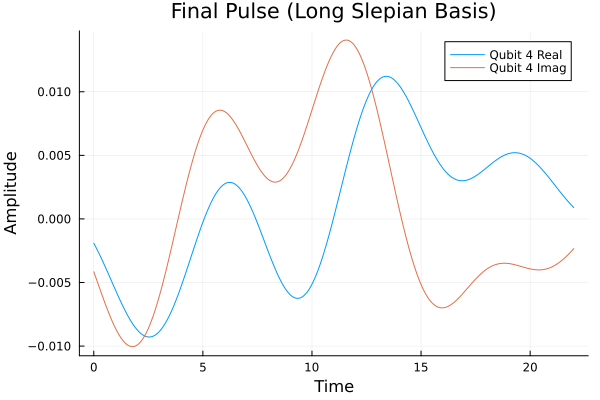

In [104]:
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/final_pulse_qubit4_long_slepian.png")
display(img)

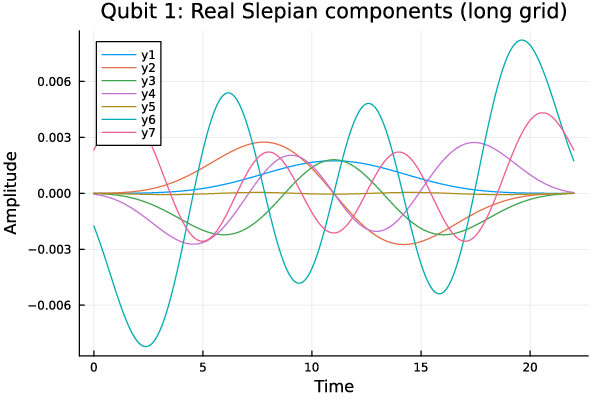

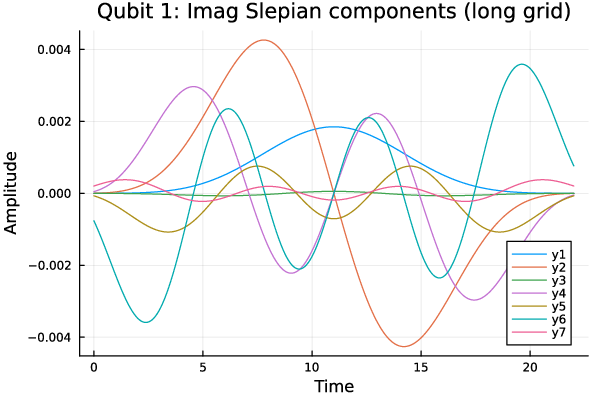

In [118]:
x_long = range(0, T, length=N_long+1)

for q in 1:n_qubits
    # For each qubit, collect individual Slepian components (real and/or imag)
    components = []
    for k in 1:K
        # Real part component
        comp_real = coeffs_final_real[k, q] * long_dpss[:, k]
        push!(components, comp_real)
    end

    # Plot all K real components overlapped for this qubit
    plot(x_long, hcat(components...),
        xlabel="Time", ylabel="Amplitude",
        title="Qubit $q: Real Slepian components (long grid)", legend=:best)
    savefig("qubit$(q)_real_slepian_components_long.pdf")

    # Imaginary part components
    components_imag = [coeffs_final_imag[k, q] * long_dpss[:, k] for k in 1:K]
    plot(x_long, hcat(components_imag...),
        xlabel="Time", ylabel="Amplitude",
        title="Qubit $q: Imag Slepian components (long grid)", legend=:best)
    savefig("qubit$(q)_imag_slepian_components_long.pdf")
end
# Display the last plot
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/qubit1_real_slepian_components_long.pdf")
display(img)    
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/qubit1_imag_slepian_components_long.pdf")
display(img)

In [119]:
x_long = range(0, T, length=N_long+1)
for q in 1:n_qubits
    pulse_long_real_q = long_dpss * coeffs_final_real[:, q]
    pulse_long_imag_q = long_dpss * coeffs_final_imag[:, q]
    # Reverse projection (recovery)
    recovered_real = long_dpss \ pulse_long_real_q
    recovered_imag = long_dpss \ pulse_long_imag_q
    println("Qubit $q real coefficients match: ",
        all(isapprox.(coeffs_final_real[:, q], recovered_real; atol=1e-8)))
    println("Qubit $q imag coefficients match: ",
        all(isapprox.(coeffs_final_imag[:, q], recovered_imag; atol=1e-8)))
end


Qubit 1 real coefficients match: true
Qubit 1 imag coefficients match: true
Qubit 2 real coefficients match: true
Qubit 2 imag coefficients match: true
Qubit 3 real coefficients match: true
Qubit 3 imag coefficients match: true
Qubit 4 real coefficients match: true
Qubit 4 imag coefficients match: true


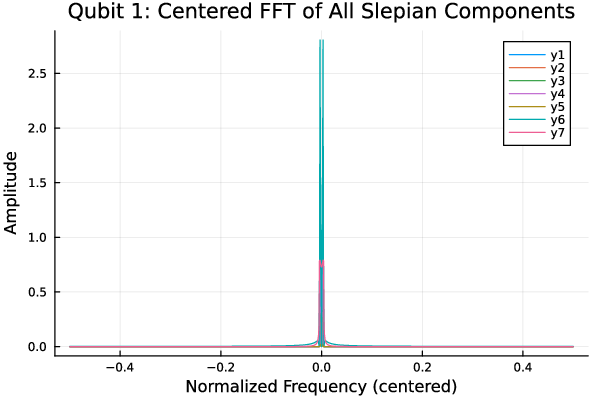

In [106]:


x_long = range(0, T, length=N_long+1)
N = length(x_long)
freq = (0:N-1) / N   # normalized frequency axis

q = 1

specs = []
for k in 1:K
    comp_real = coeffs_final_real[k, q] * long_dpss[:, k]
    fft_real = fft(comp_real)
    fft_mag = abs.(fft_real)
    fft_mag_shifted = fftshift(fft_mag)
    push!(specs, fft_mag_shifted)
end

# Make a corresponding centered frequency axis
freq = (-N ÷ 2):(N ÷ 2) 
freq = freq / N  # normalized frequency, centered

plot(freq, hcat(specs...),
    xlabel="Normalized Frequency (centered)",
    ylabel="Amplitude",
    title="Qubit $q: Centered FFT of All Slepian Components",
    legend=:best)
# savefig("qubit$(q)_centered_fft_all_slepian_components_long.pdf")
savefig("qubit$(q)_fft_all_slepian_components_long.pdf")

img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/qubit1_fft_all_slepian_components_long.pdf")
display(img)

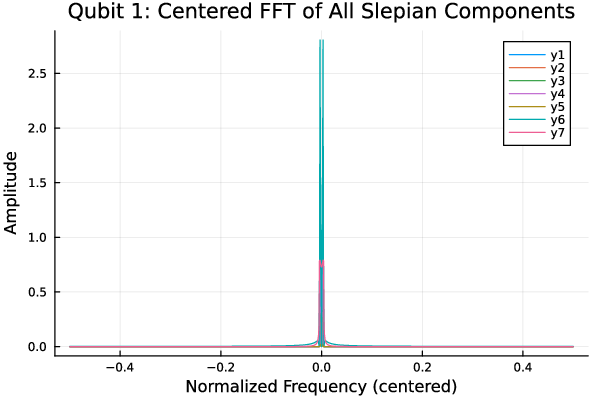

In [107]:


x_long = range(0, T, length=N_long+1)
N = length(x_long)
freq = (0:N-1) / N   # normalized frequency axis

q = 1

specs = []
for k in 1:K
    comp_real = coeffs_final_real[k, q] * long_dpss[:, k]
    fft_real = fft(comp_real)
    fft_mag = abs.(fft_real)
    fft_mag_shifted = fftshift(fft_mag)
    push!(specs, fft_mag_shifted)
end

# Make a corresponding centered frequency axis
freq = (-N ÷ 2):(N ÷ 2) 
freq = freq / N  # normalized frequency, centered

plot(freq, hcat(specs...),
    xlabel="Normalized Frequency (centered)",
    ylabel="Amplitude",
    title="Qubit $q: Centered FFT of All Slepian Components",
    legend=:best)
# savefig("qubit$(q)_centered_fft_all_slepian_components_long.pdf")
savefig("qubit$(q)_fft_all_slepian_components_long.pdf")
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/qubit1_fft_all_slepian_components_long.pdf")
display(img)

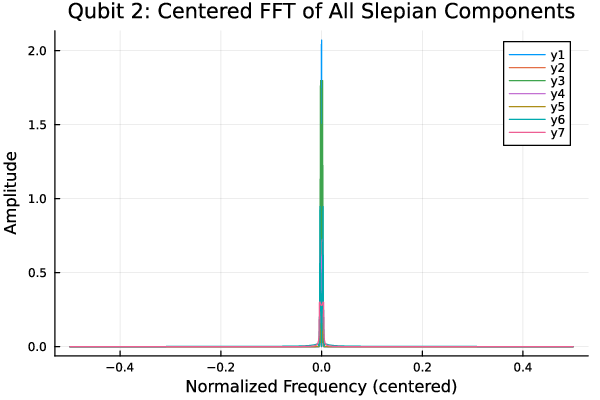

In [108]:


x_long = range(0, T, length=N_long+1)
N = length(x_long)
freq = (0:N-1) / N   # normalized frequency axis

q = 2

specs = []
for k in 1:K
    comp_real = coeffs_final_real[k, q] * long_dpss[:, k]
    fft_real = fft(comp_real)
    fft_mag = abs.(fft_real)
    fft_mag_shifted = fftshift(fft_mag)
    push!(specs, fft_mag_shifted)
end

# Make a corresponding centered frequency axis
freq = (-N ÷ 2):(N ÷ 2) 
freq = freq / N  # normalized frequency, centered

plot(freq, hcat(specs...),
    xlabel="Normalized Frequency (centered)",
    ylabel="Amplitude",
    title="Qubit $q: Centered FFT of All Slepian Components",
    legend=:best)
# savefig("qubit$(q)_centered_fft_all_slepian_components_long.pdf")
savefig("qubit$(q)_fft_all_slepian_components_long.pdf")
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/qubit2_fft_all_slepian_components_long.pdf")
display(img)

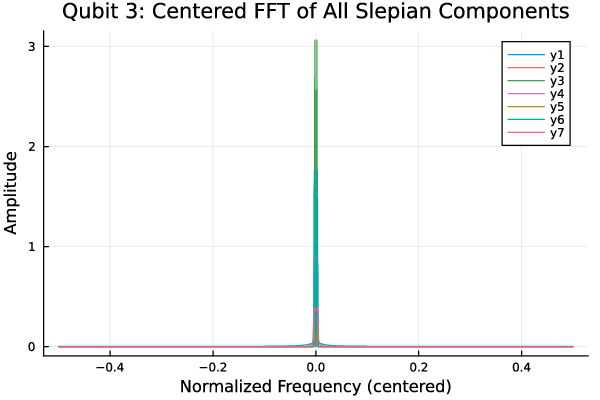

In [109]:


x_long = range(0, T, length=N_long+1)
N = length(x_long)
freq = (0:N-1) / N   # normalized frequency axis

q = 3

specs = []
for k in 1:K
    comp_real = coeffs_final_real[k, q] * long_dpss[:, k]
    fft_real = fft(comp_real)
    fft_mag = abs.(fft_real)
    fft_mag_shifted = fftshift(fft_mag)
    push!(specs, fft_mag_shifted)
end

# Make a corresponding centered frequency axis
freq = (-N ÷ 2):(N ÷ 2) 
freq = freq / N  # normalized frequency, centered

plot(freq, hcat(specs...),
    xlabel="Normalized Frequency (centered)",
    ylabel="Amplitude",
    title="Qubit $q: Centered FFT of All Slepian Components",
    legend=:best)
# savefig("qubit$(q)_centered_fft_all_slepian_components_long.pdf")
savefig("qubit$(q)_fft_all_slepian_components_long.pdf")
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/qubit3_fft_all_slepian_components_long.pdf")
display(img)

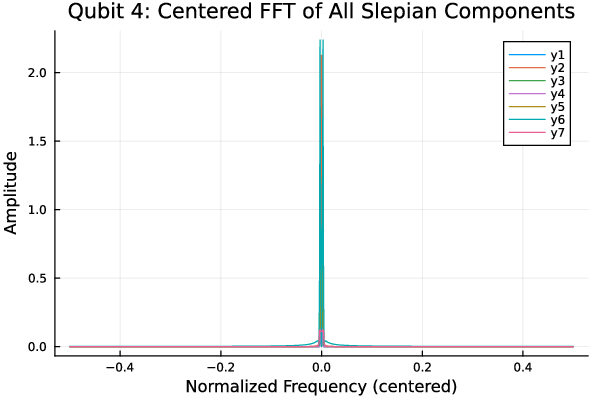

In [110]:


x_long = range(0, T, length=N_long+1)
N = length(x_long)
freq = (0:N-1) / N   # normalized frequency axis

q = 4

specs = []
for k in 1:K
    comp_real = coeffs_final_real[k, q] * long_dpss[:, k]
    fft_real = fft(comp_real)
    fft_mag = abs.(fft_real)
    fft_mag_shifted = fftshift(fft_mag)
    push!(specs, fft_mag_shifted)
end

# Make a corresponding centered frequency axis
freq = (-N ÷ 2):(N ÷ 2) 
freq = freq / N  # normalized frequency, centered

plot(freq, hcat(specs...),
    xlabel="Normalized Frequency (centered)",
    ylabel="Amplitude",
    title="Qubit $q: Centered FFT of All Slepian Components",
    legend=:best)
# savefig("qubit$(q)_centered_fft_all_slepian_components_long.pdf")
savefig("qubit$(q)_fft_all_slepian_components_long.pdf")
img = load("/Users/arnab/arnab/workspace/complex_pulse/SimpleEvolve.jl/example/qubit4_fft_all_slepian_components_long.pdf")
display(img)

In [112]:
# High resolution long Slepian basis
long_dpss

1001×7 Matrix{Float64}:
 2.8932e-6    2.70987e-5  0.000172681  …  0.00349422   0.0117551  0.0316855
 3.315e-6     3.03974e-5  0.00018974      0.00369249   0.0122022  0.0323625
 3.76695e-6   3.38909e-5  0.0002076       0.00389541   0.0126544  0.0330373
 4.25041e-6   3.75858e-5  0.000226281     0.00410302   0.0131117  0.0337095
 4.76673e-6   4.14893e-5  0.000245805     0.00431532   0.0135738  0.0343788
 5.31735e-6   4.56085e-5  0.000266191  …  0.00453232   0.0140407  0.0350449
 5.90372e-6   4.99506e-5  0.000287462     0.00475403   0.0145123  0.0357076
 6.52734e-6   5.45231e-5  0.000309639     0.00498046   0.0149884  0.0363666
 7.18975e-6   5.93334e-5  0.000332742     0.00521161   0.0154689  0.0370216
 7.89253e-6   6.43893e-5  0.000356795     0.00544748   0.0159537  0.0376722
 ⋮                                     ⋱               ⋮          
 7.18975e-6  -5.93334e-5  0.000332742     0.00521161  -0.0154689  0.0370216
 6.52734e-6  -5.45231e-5  0.000309639     0.00498046  -0.0149884  0.03636

In [113]:
coeffs_final_real

7×4 Matrix{Float64}:
  0.0278428   -0.0933659   -0.0586035   0.0478186
  0.0505265   -0.0405191   -0.0846839  -0.113086
 -0.0422125   -0.0993035    0.169163    0.0366363
 -0.0518633    0.0459174   -0.0107617  -0.00801398
 -0.00126689   0.00893102   0.0145375  -0.0459963
 -0.148558     0.050138    -0.0930584  -0.118535
  0.0732507    0.0279248    0.0357624  -0.0111866

In [114]:
coeffs_final_imag

7×4 Matrix{Float64}:
  0.0294976    0.0170159   -0.0387168   0.134564
  0.0784175   -0.0304709    0.0265528   0.0620748
 -0.00128883  -0.0204761   -0.046381   -0.0697369
  0.0564244   -0.0525461    0.0192004   0.0665068
 -0.0201196    0.0279021    0.0178185  -0.0316381
 -0.0648534    0.14027      0.0613222  -0.0824044
  0.00641253  -0.00351155  -0.0525958  -0.0985473

In [116]:
Φ

11×7 Matrix{Float64}:
 2.8932e-5    0.000270987   0.00172681  …   0.117427      0.313634
 0.00607556   0.029606      0.0945278       0.548551      0.485325
 0.0604231    0.195638      0.391074        0.0636893    -0.287977
 0.235197     0.476064      0.496576       -0.331676      0.0155683
 0.49436      0.483954     -0.0141487       0.266904      0.20405
 0.627062    -3.23963e-14  -0.427399    …  -1.44451e-14  -0.287348
 0.49436     -0.483954     -0.0141487      -0.266904      0.20405
 0.235197    -0.476064      0.496576        0.331676      0.0155683
 0.0604231   -0.195638      0.391074       -0.0636893    -0.287977
 0.00607556  -0.029606      0.0945278      -0.548551      0.485325
 2.8932e-5   -0.000270987   0.00172681  …  -0.117427      0.313634

In [115]:
samples_final

11×4 Matrix{ComplexF64}:
  0.00498121-0.00580295im   0.0151668+0.0158507im  …  -0.0190695-0.0412183im
  -0.0604085-0.0256115im    0.0438261+0.0720663im     -0.0905368-0.0949154im
  -0.0631806+0.0316709im   -0.0294401-0.0187033im     -0.0328787+0.0375694im
   0.0519178+0.0797634im    -0.101612-0.0831944im      0.0255709+0.0715777im
   0.0343236+0.0178636im   -0.0643771+0.0466703im     -0.0553635+0.0346409im
   0.0140077+0.0101445im    -0.020994+0.0302222im  …  0.00139988+0.1314im
   0.0246827+0.0201403im   -0.0164752-0.0392783im       0.111182+0.069888im
  -0.0777949-0.0563519im   -0.0447729+0.0560304im      0.0572304-0.0639133im
 -0.00973153-0.049822im    -0.0680436+0.0303626im       0.034858-0.0458488im
    0.122837+0.0155964im   -0.0293697-0.056459im       0.0497979-0.0380055im
   0.0407339+0.00841679im  0.00262516-0.0161735im  …  0.00896799-0.0230409im